In [11]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
%pip install -q -U imbalanced-learn optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 5.8 MB/s eta 0:00:00


In [10]:
!ls ~/Downloads

ls: cannot access '/root/Downloads': No such file or directory


In [12]:
# ---------------------------------------------------------
# 1. SETUP, CARGA DE DATOS E IMPUTACIÓN
# ---------------------------------------------------------
import pandas as pd
import numpy as np
import optuna
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Carga del dataset (Asegúrate de que 'water_potability.csv' esté en tu entorno)
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/water_potability.csv')
print(f"Dataset cargado con forma: {df.shape}")

# Imputación Estratégica basada en la Mediana por Clase
# Evitamos distorsionar las distribuciones imputando según si la muestra es potable o no
columnas_con_nulos = ['ph', 'Sulfate', 'Trihalomethanes']

for col in columnas_con_nulos:
    # Transformación aplicando la mediana calculada agrupando por 'Potability'
    df[col] = df[col].fillna(df.groupby('Potability')[col].transform('median'))

print("\nValores nulos tras la imputación rigurosa:")
print(df.isnull().sum())

Dataset cargado con forma: (3276, 10)

Valores nulos tras la imputación rigurosa:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [13]:
# ---------------------------------------------------------
# 2. PREPARACIÓN DE MACHINE LEARNING: SMOTE Y SCALING
# ---------------------------------------------------------
# Separar características (X) y variable objetivo (y)
X = df.drop('Potability', axis=1)
y = df['Potability']

# Balanceo de Clases usando SMOTE (Synthetic Minority Over-sampling Technique)
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X, y)

print(f"\nDistribución tras SMOTE:\n{y_bal.value_counts()}")

# División Estratificada 80/20 (para mantener la proporción de la variable objetivo)
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.20, random_state=42, stratify=y_bal
)

# Estandarización Rigurosa
# ATENCIÓN: El StandardScaler se ajusta (fit) SOLO con X_train para evitar el Data Leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Distribución tras SMOTE:
Potability
0    1998
1    1998
Name: count, dtype: int64


In [14]:
# ---------------------------------------------------------
# 3. OPTIMIZACIÓN Y ENTRENAMIENTO SVM (Línea Base)
# ---------------------------------------------------------
def objective(trial):
    # Definimos el espacio de búsqueda logarítmico y categórico
    c_param = trial.suggest_float('C', 0.1, 100.0, log=True)
    gamma_param = trial.suggest_categorical('gamma', ['scale', 'auto', 0.01, 0.1, 1.0])

    # Creamos el estimador
    svc = SVC(kernel='rbf', C=c_param, gamma=gamma_param, random_state=42)

    # Validación Cruzada de 5 particiones utilizando F1-Score como métrica norte
    score = cross_val_score(svc, X_train_scaled, y_train, cv=5, scoring='f1').mean()
    return score

print("\nIniciando optimización de hiperparámetros con Optuna...")
optuna.logging.set_verbosity(optuna.logging.WARNING) # Para mantener la consola limpia
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30) # 30 trials de búsqueda

print(f"\nMejores Hiperparámetros encontrados: {study.best_params}")

# Entrenar el modelo final con el conjunto de entrenamiento completo y mejores parámetros
best_svc = SVC(kernel='rbf', **study.best_params, random_state=42)
best_svc.fit(X_train_scaled, y_train)

# Predicción sobre datos jamás vistos (X_test)
y_pred = best_svc.predict(X_test_scaled)


Iniciando optimización de hiperparámetros con Optuna...

Mejores Hiperparámetros encontrados: {'C': 18.57623345650744, 'gamma': 0.1}



================ REPORTE DE MÉTRICAS ================
Accuracy (Exactitud):  0.6625
Precision (Precisión): 0.6601
Recall (Exhaustividad):0.6700
F1-Score:              0.6650


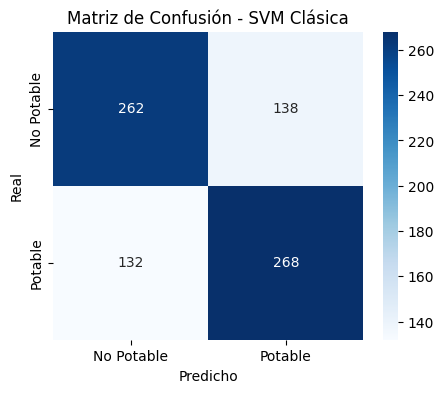


========== SUBCONJUNTO CUÁNTICO AISLADO ==========
Forma de características (X_quantum): (64, 9)
Distribución de etiquetas (y_quantum): [32 32] (Debe ser [32 32])


In [15]:
# ---------------------------------------------------------
# 4. EVALUACIÓN Y SUBCONJUNTO CUÁNTICO
# ---------------------------------------------------------
print("\n================ REPORTE DE MÉTRICAS ================")
print(f"Accuracy (Exactitud):  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (Precisión): {precision_score(y_test, y_pred):.4f}")
print(f"Recall (Exhaustividad):{recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:              {f1_score(y_test, y_pred):.4f}")
print("=====================================================")

# Visualización de la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Potable', 'Potable'], yticklabels=['No Potable', 'Potable'])
plt.title('Matriz de Confusión - SVM Clásica')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

# ---------------------------------------------------------
# EXTRACCIÓN DEL SUBCONJUNTO PARA QSVM (64 muestras)
# ---------------------------------------------------------
# Utilizamos StratifiedShuffleSplit para garantizar que se extraigan
# proporciones exactas de la data nunca antes vista
splitter = StratifiedShuffleSplit(n_splits=1, train_size=64, random_state=42)

for sub_idx, _ in splitter.split(X_test_scaled, y_test):
    X_quantum_subset = X_test_scaled[sub_idx]
    y_quantum_subset = y_test.iloc[sub_idx].values

print("\n========== SUBCONJUNTO CUÁNTICO AISLADO ==========")
print(f"Forma de características (X_quantum): {X_quantum_subset.shape}")
print(f"Distribución de etiquetas (y_quantum): {np.bincount(y_quantum_subset)} (Debe ser [32 32])")